# ENSO (Niño3.4) — alternate spin-ups vs Full-CPL

Figures:
* `PSD_Nino34_SST_Welch_yr251-yr350.pdf`
* `mpasTimeSeriesOcean_nino34_index_Nino3.4_yr1-yr350.pdf`
* `mpasTimeSeriesOcean_ts_SST_Nino3.4_yr1-yr350.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

from typing import Optional, Tuple, List
import os, re, glob, json
import numpy as np
import xarray as xr
import cftime
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.ticker import (
    FixedLocator, FixedFormatter, AutoMinorLocator,
    MultipleLocator, NullFormatter
)
from matplotlib.lines import Line2D

import statsmodels.api as sm
from scipy import stats
import os, glob, re, json
import pandas as pd 
from scipy import signal, stats
from scipy.signal import windows
from matplotlib.ticker import FixedLocator, FixedFormatter, MultipleLocator, NullFormatter

from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish
from util.regional_timeseries import NinoIndexPlotter, NinoSSTPlotter, OCNEnsoSpectrum

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/enso"
DATA_DIR     = f"{OUTPUT_ROOT}/data/enso"                  # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPS        = ["Full-CPL", "AltBG1", "AltBG2"]   # experiments compared (plotting order)
COLORS      = ["black", "#cc0000", "#377eb8"]    # one per experiment
YEARS       = (1, 350)      # simulation years analysed (selects the MPAS-Analysis ts_0001-0350 run)
CLIMO_LEN   = 50            # climatology length of that MPAS-Analysis run (climo_0301-0350)
SWITCH_YEAR = 221           # vertical marker: first piControl year of the AltBG runs
SPECTRUM_YEARS = 100        # Nino3.4 spectrum over the last N years of YEARS


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/enso
data    -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/enso
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/enso


## 1 Niño3.4 SST
### Settings

In [4]:
# === Paths ===
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
fig_dir     = FIG_DIR
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# Window & labels
step_yrs = 25
ref_yrs = [SWITCH_YEAR]
climo_len = CLIMO_LEN

time_unit = "0001-01-01 00:00:00"
calendar = "noleap"
ts_window = YEARS
year_min, year_max = ts_window

# IMPORTANT: keep year_token >= 0001 to avoid negative slice if time decoding falls back
year_token = f"{year_min:04d}-{year_max:04d}"

# Per-experiment subdirs (in desired plotting order)
exp_type = "spin-up"
exp_tags = EXPS
labels = [LABEL[t] for t in EXPS]

exp_subdirs = build_exp_subdirs_from_run_dict(
    run_dict=run_dict,
    exp_tags=exp_tags,
    exp_type=exp_type,
    ts_window=ts_window,
    climo_len=climo_len,
    ts_base="post/analysis/mpas_analysis",
)
exps = list(exp_subdirs.keys())

# Variable to plot (absolute SST)
file_key = "mpasTimeSeriesOcean"
vname   = "SST"
mpasvar = "timeMonthly_avg_avgValueWithinOceanRegion_avgSurfaceTemperature"
vunit   = r"$^o$C"
vfac    = 1.0
y_label = fr"{vname} ({vunit})"
x_label = "Model Time (year)"

reg_dict = {
    "Arctic"         : {"name": "arctic",     "index": 0, "min": 17.2, "max": 18.8},
    "Equator"        : {"name": "equatorial", "index": 1, "min": 17.2, "max": 18.8},
    "Southern Ocean" : {"name": "so",         "index": 2, "min": 17.2, "max": 18.8},
    "Nino3"          : {"name": "nino3",      "index": 3, "min": 17.2, "max": 18.8},
    "Nino4"          : {"name": "nino4",      "index": 4, "min": 17.2, "max": 18.8},
    "Nino3.4"        : {"name": "nino3.4",    "index": 5, "min": 21.0, "max": 31.0},
    "Global"         : {"name": "global",     "index": 6, "min": 17.2, "max": 18.8},
}

region = "Nino3.4"
reg_dim  = "nOceanRegions"
reg_ind  = reg_dict[region]["index"]
ylim     = (reg_dict[region]["min"], reg_dict[region]["max"])
title    = f"(a) Sea Surface Temperature (SST) ({region})"

# Stats windows (last-N-year)
trend_years = 100
trend_unit  = "per_decade"
figsize     = (24, 12)    # two stacked panels
fontsize    = 28

# ---- Choose how to display SST on LEFT axis ----
# Option 1: annual mean SST (simple)
# annual_mean = True
# running_mean = False
# running_mean_months = 0

# Option 2 (recommended for posters): monthly SST smoothed with 12-month running mean
annual_mean = False
running_mean = True
running_mean_months = 12
running_mean_center = "center"

compute_anomaly = False

# Filtering
use_filter = False
filt_method = "pad"
filt_padtype = "odd"
filt_padlen = None
baseline_months = 12
filt_cutoff_months = 12
filt_order = 4

# Std band for SST plot
std_band = True
std_center = "filtered"
std_source = "raw"
std_mode = "global"
legend_loc = "best"
legend_note = None
show_raw = False
show_raw_faint = False
edge_fix_points = 1
engine = "netcdf4"
chunks = None

title_sst = f"(a) Sea Surface Temperature (SST) (Niño3.4)"
# SST panels: Full-CPL (index 0) vs each alternate spin-up, stacked top to bottom
sst_panels = [[0, i] for i in range(1, len(EXPS))]
sst_panel_titles = [f"({chr(97 + k)}) Niño3.4 SST: {LABEL[EXPS[0]]} vs {LABEL[EXPS[i]]}"
                    for k, (_, i) in enumerate(sst_panels)]

# hatched windows per experiment (same as 2_ocn_sfc_compare_analysis), colored like each run's line
exp_shas = {
    "Full-CPL": None,
    "AltBG1": {"segments": [(11, 20), (81, 90), (151, 160)], "alpha": 0.4, "hatch": "///"},
    "AltBG2": {"segments": [(11, 50)],                       "alpha": 0.4, "hatch": ".."},
}
sst_shas = {EXPS.index(t): sha for t, sha in exp_shas.items() if sha and t in EXPS}
title_idx = f"(b) Niño3.4 Index"
ylab_idx = f"Niño3.4 index (°C)"
ylim_idx = (-5, 5)
idx_base_years = 30
idx_smooth_months = 5
linestyle = "-" 
linewidth = 2.5 
alpha = 0.9
add_zero_line = True

colors = list(COLORS)
default_subdir = "."


### Compute & plot

/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings/20231209.v3.LR.piControl-spinup.chrysalis/post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries
['/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings/20231209.v3.LR.piControl-spinup.chrysalis/post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries/mpasTimeSeriesOcean.nc']
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings/20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis/post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries
['/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings/20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis/post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries/mpasTimeSeriesOcean.nc']
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings/20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis/post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries
['/lcrc/group/e3sm/ac.szhang/acme_sc

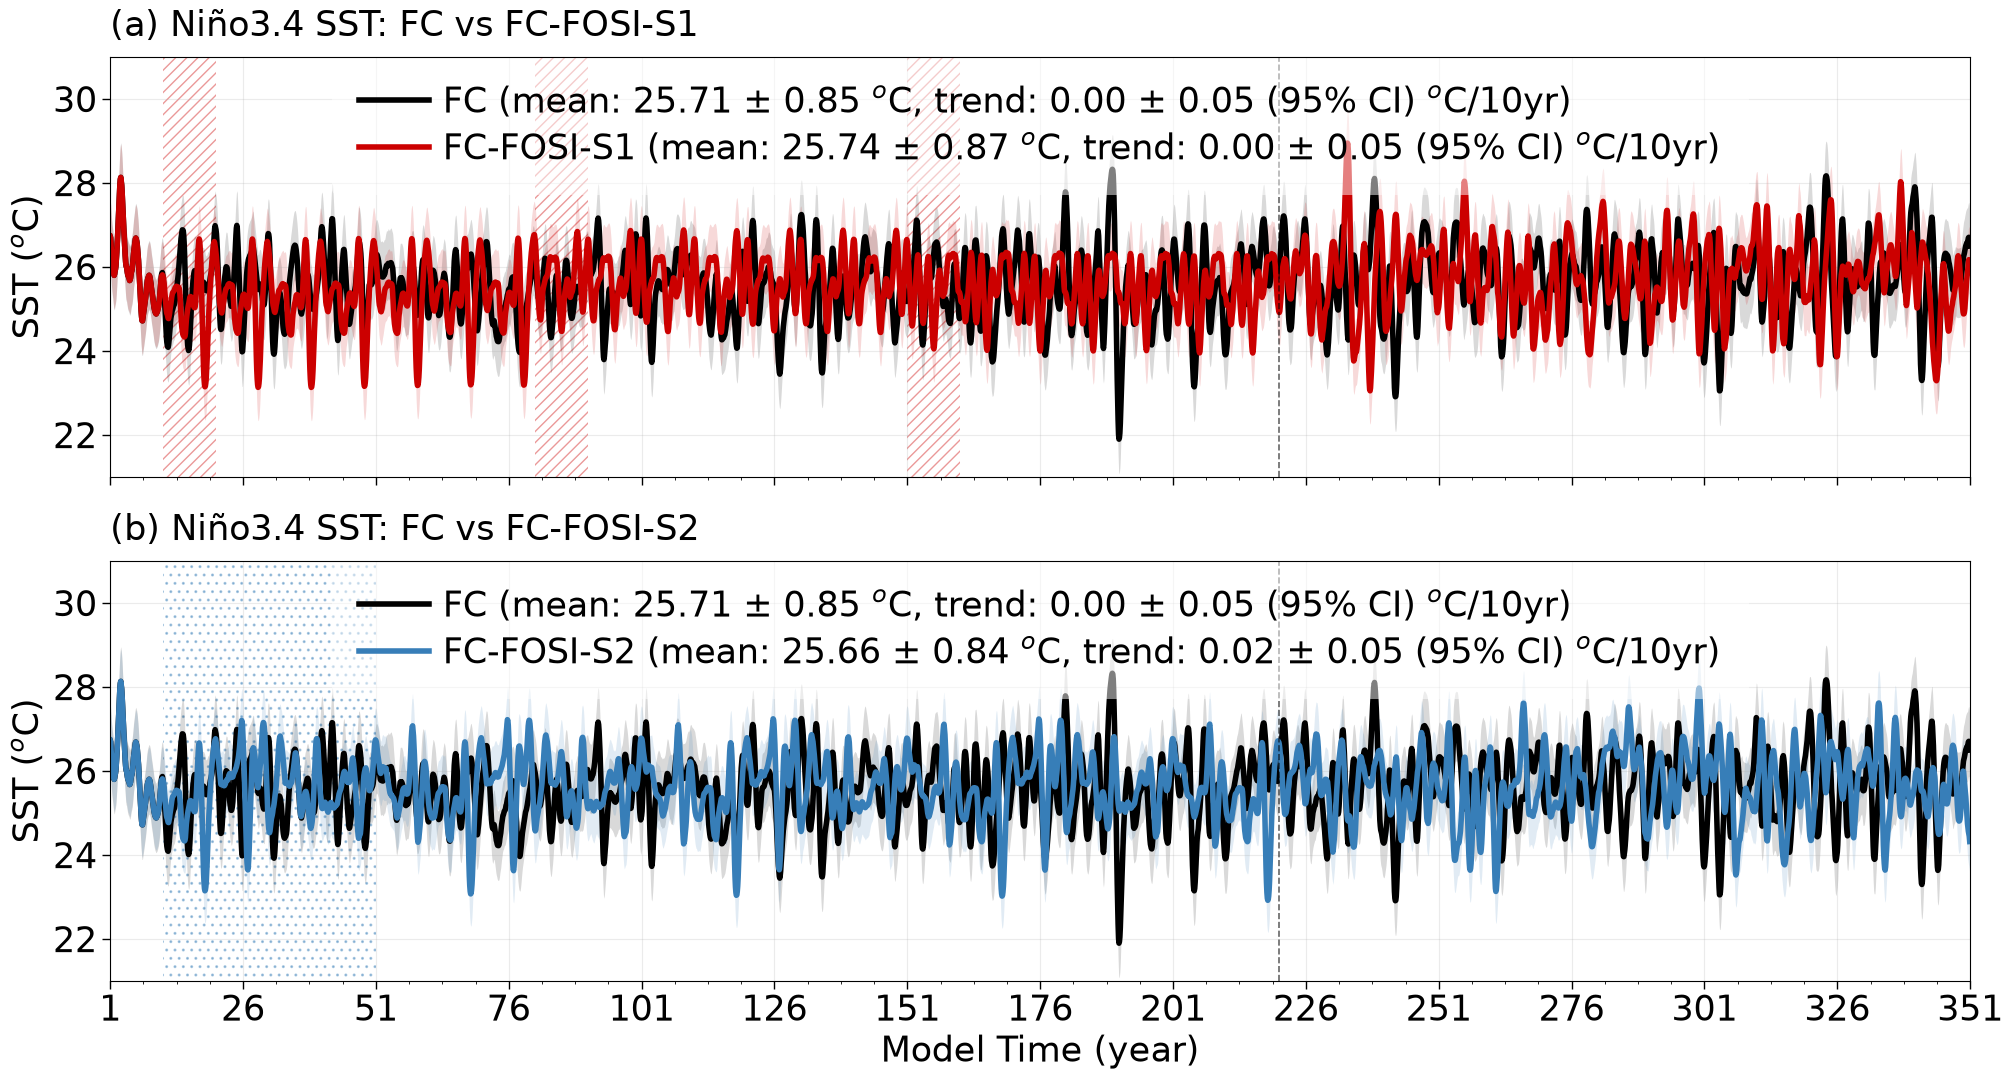

In [5]:
plotter = NinoSSTPlotter(
    root_dir=data_dir,
    sub_dir=default_subdir,
    file_key=file_key,
    region_index=reg_ind,
    region_dim=reg_dim,
    region_names_var=None,
    var_name=mpasvar,
    annual_mean=annual_mean,
    running_mean=running_mean,                  # <<< IMPORTANT: actually enable
    running_mean_months=running_mean_months,
    running_mean_center=running_mean_center,
    compute_anomaly=compute_anomaly,
    scale=vfac,
    baseline_months=baseline_months,
    filt_cutoff_months=filt_cutoff_months,
    filt_order=filt_order,
    trend_years=trend_years,
    trend_unit=trend_unit,
    year_min=year_min,
    year_max=year_max,
    use_filter=use_filter,
    filt_method=filt_method,
    filt_padtype=filt_padtype,
    filt_padlen=filt_padlen,
    edge_fix_points=edge_fix_points,
    engine=engine,
    chunks=chunks,
    time_origin=time_unit,
    calendar=calendar,
)

for i, exp in enumerate(exps):
    plotter.add_experiment(
        exp,
        label=labels[i],
        year_token=year_token,
        color=colors[i % len(colors)],
        linewidth=4.0,
        alpha=1.0,
        sub_dir=exp_subdirs.get(exp),
    )

# -------------------------
# Cache plot-ready Niño3.4 index data
# -------------------------
out_nc_idx = os.path.join(
    out_dir,
    f"{file_key}_ts_{vname}_{region}_yr{year_min:04d}-yr{year_max:04d}.nc"
)

plotter.save_nino_plot_data(
    out_nc_idx,
    base_years=idx_base_years,
    smooth_months=idx_smooth_months,
    window=60,                 # matches your plot_nino_index default
    ref_yrs=ref_yrs,
    labels_zero_based=False,
)

print(f"[cache] wrote: {out_nc_idx}")

# -------------------------
# Figure 1: SST (absolute)
# -------------------------
out_pdf_sst = f"{file_key}_ts_{vname}_{region}_yr{year_min}-yr{year_max}.pdf"

plotter.plot(
    vname=vname,
    vunit=vunit,
    ylim=ylim,
    title=title_sst,
    panels=sst_panels,
    panel_titles=sst_panel_titles,
    exp_shas=sst_shas,
    y_label=y_label,
    x_label=x_label,
    figsize=figsize,
    fontsize=fontsize,
    ref_yrs=ref_yrs,
    colors=colors,
    step_yrs=step_yrs,
    outname=os.path.join(fig_dir, out_pdf_sst),
    std_band=std_band,
    std_center=std_center,
    std_source=std_source,
    std_mode=std_mode,
    show_raw=show_raw,
    show_raw_faint=show_raw_faint,
    legend_loc=legend_loc,
    legend_note=legend_note,
)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


## 2 Niño3.4 index
### Settings

In [6]:
# === Paths ===
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
fig_dir     = FIG_DIR
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# Window & labels
step_yrs = 25
ref_yrs = [SWITCH_YEAR]
climo_len = CLIMO_LEN

time_unit = "0001-01-01 00:00:00"
calendar = "noleap"
ts_window = YEARS
year_min, year_max = ts_window

# IMPORTANT: keep year_token >= 0001 to avoid negative slice if time decoding falls back
year_token = f"{year_min:04d}-{year_max:04d}"

# Per-experiment subdirs (in desired plotting order)
exp_type = "spin-up"
exp_tags = EXPS
labels = [LABEL[t] for t in EXPS]

exp_subdirs = build_exp_subdirs_from_run_dict(
    run_dict=run_dict,
    exp_tags=exp_tags,
    exp_type=exp_type,
    ts_window=ts_window,
    climo_len=climo_len,
    ts_base="post/analysis/mpas_analysis",
)
exps = list(exp_subdirs.keys())

# Variable to plot (absolute SST)
file_key = "mpasTimeSeriesOcean"
vname   = "SST"
mpasvar = "timeMonthly_avg_avgValueWithinOceanRegion_avgSurfaceTemperature"
vunit   = r"$^o$C"
vfac    = 1.0
y_label = fr"{vname} ({vunit})"
x_label = "Model Time (year)"

reg_dict = {
    "Arctic"         : {"name": "arctic",     "index": 0, "min": 17.2, "max": 18.8},
    "Equator"        : {"name": "equatorial", "index": 1, "min": 17.2, "max": 18.8},
    "Southern Ocean" : {"name": "so",         "index": 2, "min": 17.2, "max": 18.8},
    "Nino3"          : {"name": "nino3",      "index": 3, "min": 17.2, "max": 18.8},
    "Nino4"          : {"name": "nino4",      "index": 4, "min": 17.2, "max": 18.8},
    "Nino3.4"        : {"name": "nino3.4",    "index": 5, "min": 23.0, "max": 29.0},
    "Global"         : {"name": "global",     "index": 6, "min": 17.2, "max": 18.8},
}

region = "Nino3.4"
reg_dim  = "nOceanRegions"
reg_ind  = reg_dict[region]["index"]
ylim     = (reg_dict[region]["min"], reg_dict[region]["max"])
title    = f"(a) Sea Surface Temperature (SST) ({region})"

# Stats windows (last-N-year)
trend_years = 100
trend_unit  = "per_decade"
figsize     = (20, 15)
fontsize    = 24

# ---- Choose how to display SST on LEFT axis ----
# Option 1: annual mean SST (simple)
# annual_mean = True
# running_mean = False
# running_mean_months = 0

edge_fix_points = 1
engine = "netcdf4"
chunks = None
legend_loc = "best"
legend_note = None

# Option 2 (recommended for posters): monthly SST smoothed with 12-month running mean
annual_mean = False
running_mean = True
running_mean_months = 12
running_mean_center = "center"

compute_anomaly = False

# Filtering
use_filter = False
filt_method = "pad"
filt_padtype = "odd"
filt_padlen = None
baseline_months = 12
filt_cutoff_months = 12
filt_order = 4

panel_layout = "row"
separate_panels = True
title_idx = f"Niño3.4 Index"
ylab_idx = f"(°C)"
ylim_idx = (-5, 5)
idx_base_years = 30
idx_smooth_months = 5
linestyle = "-" 
linewidth = 2.5 
alpha = 0.9
add_zero_line = True

colors = list(COLORS)
default_subdir = "."

# hatched windows per experiment: same windows/style as the SST figure (section 1, `exp_shas`),
# drawn in each experiment's own panel (here the FOSI panels), colored like its line
idx_shas = {EXPS.index(t): sha for t, sha in exp_shas.items() if sha and t in EXPS}


### Compute & plot

/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings/20231209.v3.LR.piControl-spinup.chrysalis/post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries
['/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings/20231209.v3.LR.piControl-spinup.chrysalis/post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries/mpasTimeSeriesOcean.nc']
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings/20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis/post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries
['/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings/20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis/post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries/mpasTimeSeriesOcean.nc']
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings/20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis/post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries
['/lcrc/group/e3sm/ac.szhang/acme_sc

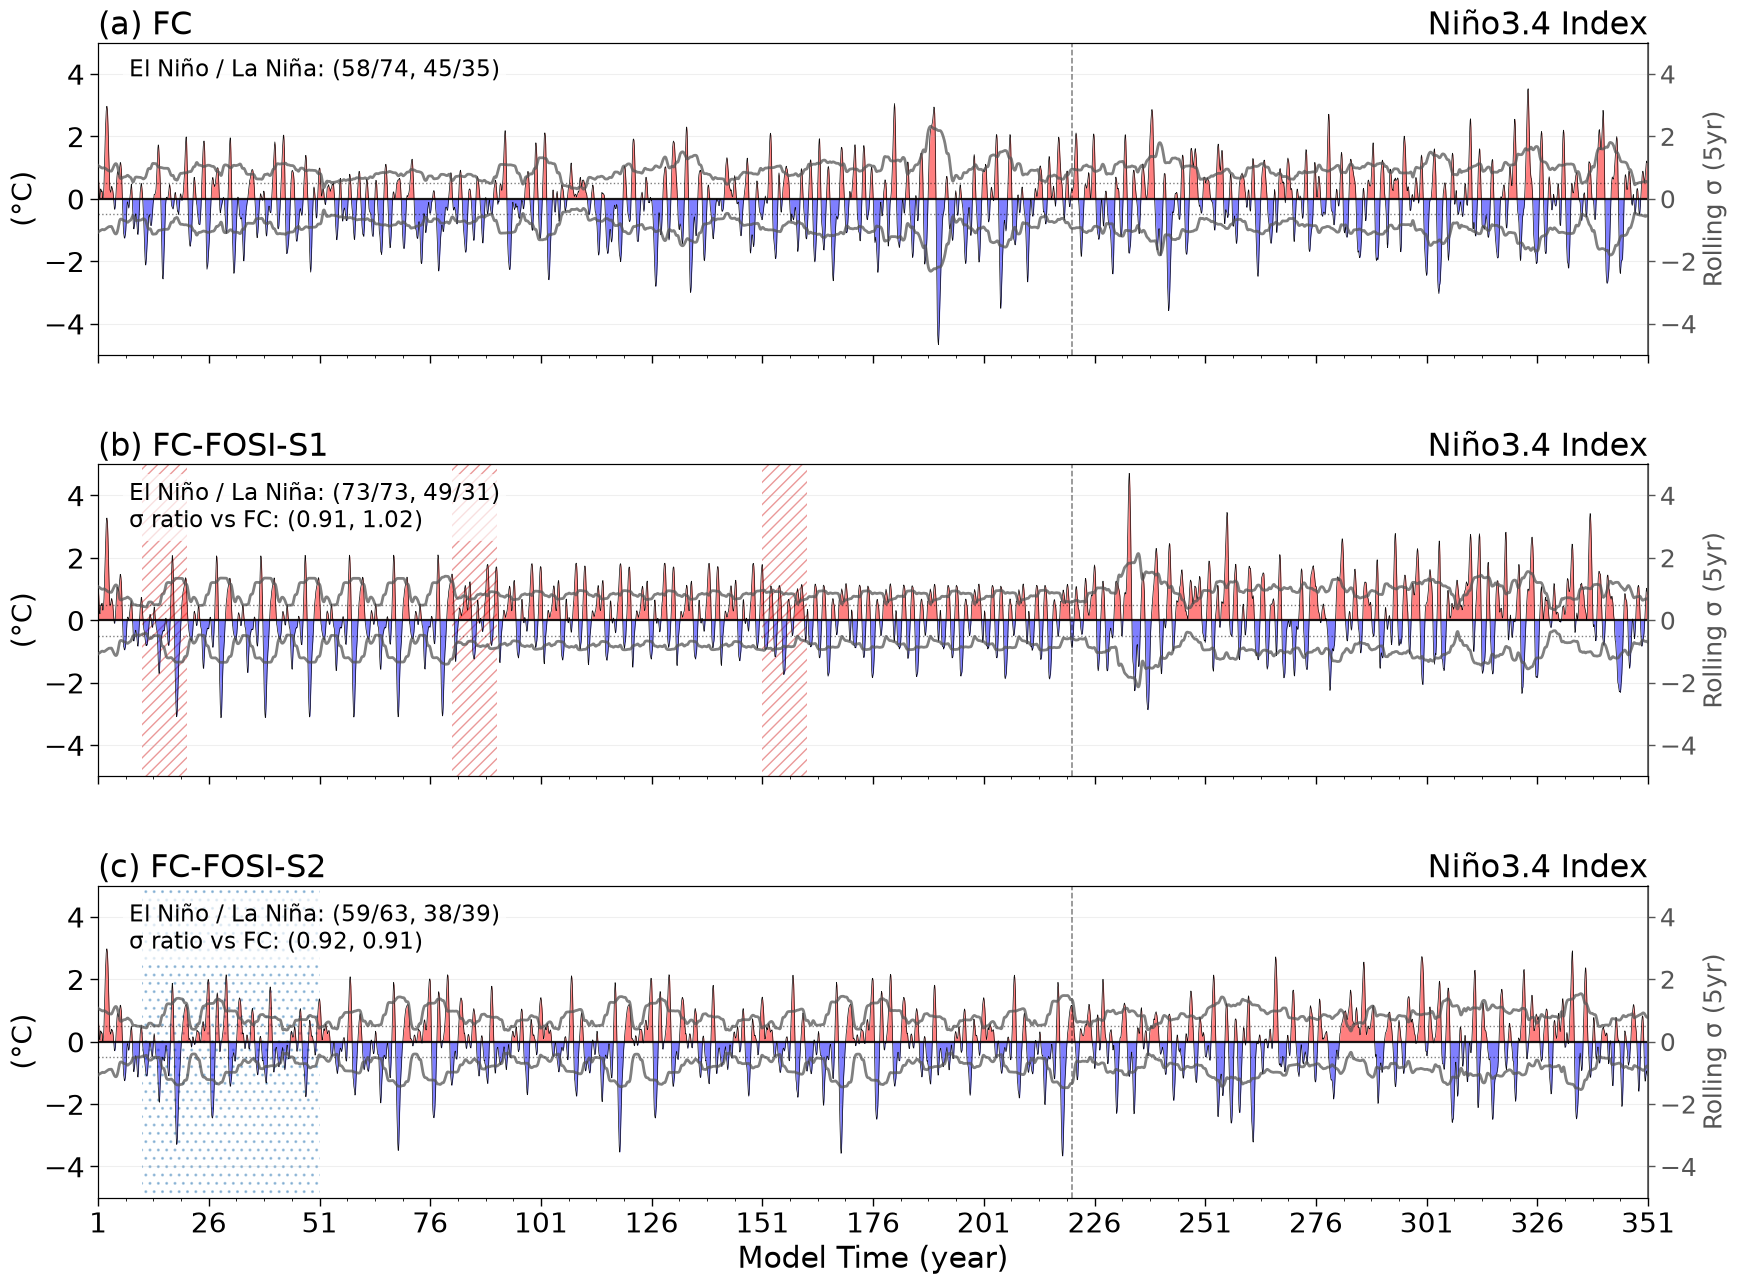

In [7]:
plotter = NinoIndexPlotter(
    root_dir=data_dir,
    sub_dir=default_subdir,
    file_key=file_key,
    region_index=reg_ind,
    region_dim=reg_dim,
    region_names_var=None,
    var_name=mpasvar,
    annual_mean=annual_mean,
    running_mean=running_mean,                  # <<< IMPORTANT: actually enable
    running_mean_months=running_mean_months,
    running_mean_center=running_mean_center,
    compute_anomaly=compute_anomaly,
    scale=vfac,
    baseline_months=baseline_months,
    filt_cutoff_months=filt_cutoff_months,
    filt_order=filt_order,
    trend_years=trend_years,
    trend_unit=trend_unit,
    year_min=year_min,
    year_max=year_max,
    use_filter=use_filter,
    filt_method=filt_method,
    filt_padtype=filt_padtype,
    filt_padlen=filt_padlen,
    edge_fix_points=edge_fix_points,
    engine=engine,
    chunks=chunks,
    time_origin=time_unit,
    calendar=calendar,
)

for i, exp in enumerate(exps):
    plotter.add_experiment(
        exp,
        label=labels[i],
        year_token=year_token,
        color=colors[i % len(colors)],
        linewidth=4.0,
        alpha=1.0,
        sub_dir=exp_subdirs.get(exp),
    )

# -------------------------
# Cache plot-ready Niño3.4 index data
# -------------------------
out_nc_idx = os.path.join(
    out_dir,
    f"{file_key}_nino34_index_{region}_yr{year_min:04d}-yr{year_max:04d}.nc"
)

plotter.save_nino_plot_data(
    out_nc_idx,
    base_years=idx_base_years,
    smooth_months=idx_smooth_months,
    window=60,                 # matches your plot_nino_index default
    ref_yrs=ref_yrs,
    labels_zero_based=False,
)

print(f"[cache] wrote: {out_nc_idx}")

# -------------------------
# Figure 2: Niño3.4 Index
# -------------------------
out_pdf_idx = f"{file_key}_nino34_index_{region}_yr{year_min}-yr{year_max}.pdf"

plotter.plot_nino_index(
    title=title_idx,
    y_label=ylab_idx,
    ylim=ylim_idx,                       
    x_label=x_label,
    colors=colors,
    figsize=figsize,
    fontsize=fontsize,
    step_yrs=step_yrs,
    ref_yrs=ref_yrs,
    outname=os.path.join(fig_dir, out_pdf_idx),
    legend_loc=legend_loc,
    legend_note=legend_note,
    base_years=idx_base_years,
    smooth_months=idx_smooth_months,
    linestyle=linestyle,
    linewidth=linewidth,
    alpha=alpha,
    add_zero_line=add_zero_line,
    exp_shas=idx_shas,
)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


## 3 Niño3.4 power spectrum
### Settings

In [8]:
# === Paths ===
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
fig_dir     = FIG_DIR  # or os.path.join(results_dir, "figures")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# ---- Config ----
climo_len = CLIMO_LEN
time_origin = "0001-01-01 00:00:00"
ts_window = YEARS  # slice files to full available window; we'll still take last N yrs for PSD
year_token = f"{ts_window[0]:04d}-{ts_window[1]:04d}"  # "0001-0350"

# Experiments
exp_type = "spin-up"
exp_tags = EXPS
labels_in = [LABEL[t] for t in EXPS]

# Build subdirs from your run_dict helper
exp_subdirs = build_exp_subdirs_from_run_dict(
    run_dict=run_dict,
    exp_tags=exp_tags,
    exp_type=exp_type,
    ts_window=ts_window,
    climo_len=climo_len,
    ts_base="post/analysis/mpas_analysis",
)
if not exp_subdirs:
    raise ValueError("No experiments returned by build_exp_subdirs_from_run_dict. Check run_dict/paths.")

# Robust ordering to match exp_tags (case-insensitive), then append any leftovers
keys = list(exp_subdirs.keys())
used, exps_ordered = set(), []
for tag in exp_tags:
    cand = [k for k in keys if tag.lower() in k.lower()]
    pick = cand[0] if cand else None
    if pick and pick not in used:
        exps_ordered.append(pick); used.add(pick)
for k in keys:
    if k not in used:
        exps_ordered.append(k)

# Colors (ensure enough)
colors = list(COLORS)
if len(colors) < len(exps_ordered):
    colors = (colors * ((len(exps_ordered) + len(colors) - 1) // len(colors)))[:len(exps_ordered)]

# Variable (Niño-3.4 SST)
file_key = "mpasTimeSeriesOcean"
mpasvar  = "timeMonthly_avg_avgValueWithinOceanRegion_avgSurfaceTemperature"
reg_dim  = "nOceanRegions"
reg_ind  = 5  # Nino3.4 region index in your MPAS region order

# PSD window
spectrum_years = SPECTRUM_YEARS
enso_year1 = ts_window[1] - spectrum_years + 1
enso_year2 = ts_window[1]

#title  = f"Niño3.4 SST Power Spectrum ({enso_year1}-{enso_year2})"
title  = f"Niño3.4 Spectrum"

ylabel = r"Power ($^\circ$C$^2$ / cycles mo$^{-1}$)"
enso_band = (2.0, 7.0)     # shade canonical ENSO band in YEARS
xlim      = (10, 1)        # reversed axis (10→1 years)
ylim      = (0, 80.0)      # set if you want fixed y-range; else set to None

# Welch config (monthly anomalies; fs=1/month internally)
nperseg   = 256            # segment length (months)
noverlap  = 128            # overlap (months)
method    =  "Welch"       # "mpas"  

detrend   = 'linear'
window    = 'hann'
normalize = False          # absolute power (matches your reference style)
add_reference = False #True 

# Figure
figsize  = (30,8)         # 3 panels in one row
fontsize = 30
fig_idx = 3


### Compute & plot

[INFO] file slice used: idx 0:4200  (0001-01-01 01:00:00 → 0350-12-01 00:00:00),  4200 months
[INFO] PSD window (20231209.v3.LR.piControl-spinup.chrysalis): 0251-01-01 00:00:00 → 0350-12-01 00:00:00  |  1200 months (~100.0 yrs)
[INFO] file slice used: idx 0:4200  (0001-01-01 01:00:00 → 0350-12-01 00:00:00),  4200 months
[INFO] PSD window (20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis): 0251-01-01 00:30:00 → 0350-12-01 00:00:00  |  1200 months (~100.0 yrs)
[INFO] file slice used: idx 0:4200  (0001-01-01 01:00:00 → 0350-12-01 00:00:00),  4200 months
[INFO] PSD window (20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis): 0251-01-01 00:00:00 → 0350-12-01 00:00:00  |  1200 months (~100.0 yrs)
exp_subdirs: {'20231209.v3.LR.piControl-spinup.chrysalis': 'post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries', '20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis': 'post/analysis/mpas_analysis/ts_0001-0350_climo_0301-0350/timeseries', '20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis': 'post

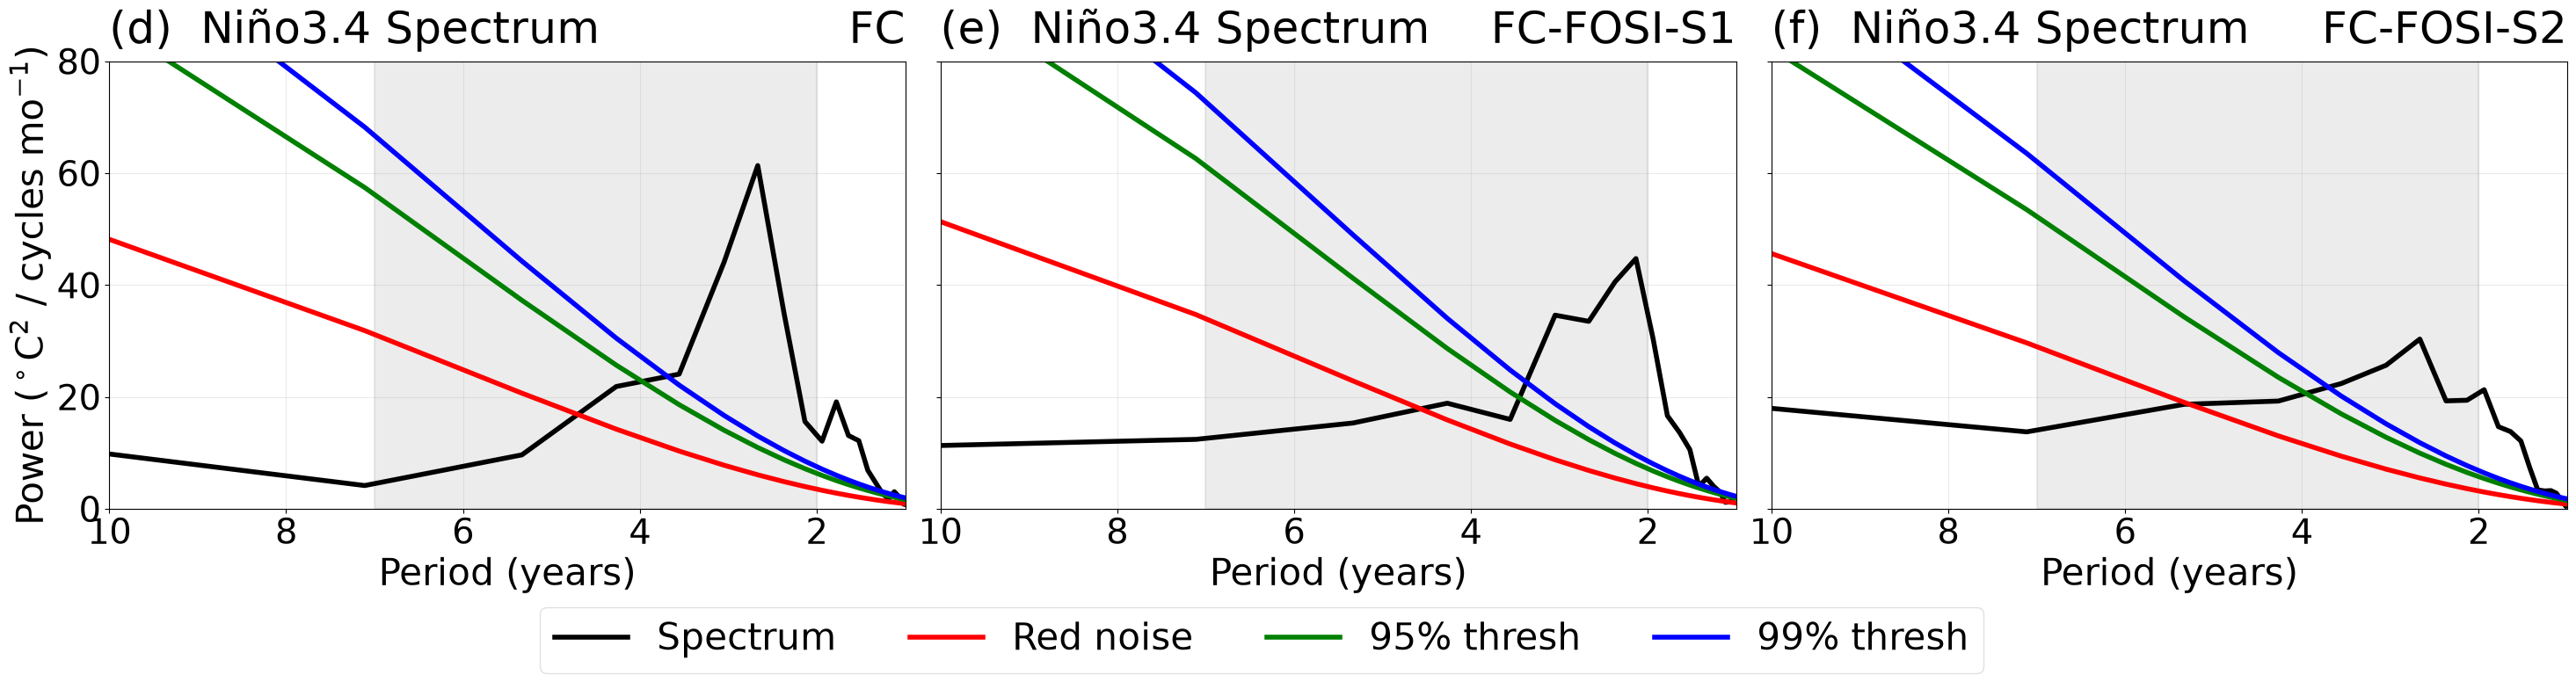

In [9]:
# === Instantiate ===
loader = OCNEnsoSpectrum(
    root_dir=data_dir,
    file_key=file_key,
    var_name=mpasvar,
    region_dim=reg_dim,
    region_index=reg_ind,
    engine="netcdf4",
    calendar="noleap",
    time_origin=time_origin,
)

# === Mapping in ordered form ===
exp_to_subdir = {exp: exp_subdirs[exp] for exp in exps_ordered}
# labels keyed by experiment so a skipped run cannot shift labels
labels_map = dict(zip(exps_ordered, labels_in))

# === Compute PSDs (last spectrum_years years) ===
psd_dict = loader.compute_psd_with_rednoise(
    exp_to_subdir=exp_to_subdir,
    year_token=year_token,
    last_years=spectrum_years,
    nperseg=nperseg,
    noverlap=noverlap,
    detrend=detrend,
    window=window,
    normalize=normalize,
    method=method,     # default; use "cvdp" to compare with CVDP/NCL-style
)

# Quick sanity print
print("exp_subdirs:", exp_subdirs)
print("exps_ordered:", exps_ordered)
print("exp_to_subdir:", exp_to_subdir)
if not psd_dict:
    raise RuntimeError("No spectra computed — check the printed mappings above.")

# Name outputs by the years actually used (not the configured ones)
win = {w for e, w in getattr(loader, "_last_window_years", {}).items() if e in psd_dict}
if len(win) == 1 and None not in win:
    enso_year1, enso_year2 = win.pop()
else:
    print(f"[WARN] PSD windows differ or are unknown across experiments: {win}; "
          f"file names use configured years {enso_year1}-{enso_year2}")

if add_reference:
    # 1) Build a HadSST Niño-3.4 reference (anomalies):
    hadsst_path = os.path.join(OBS_DIR, "hadsst_1870_1969_nino34_raw.nc")
    h_series, h_time = loader.load_nino34_series_from_file(hadsst_path, already_anomalies=False)
    # 2) Compute PSD over the same analysis window as your models (e.g., last 50 years)
    h_psd = loader.compute_reference_psd_from_file(
        hadsst_path,
        last_years=int(spectrum_years),    # or use year_token="1870-1969"
        already_anomalies=False,           # file is "raw" monthly => deseasonalize inside
        method=method, 
        nperseg=nperseg, 
        noverlap=noverlap,
        label="HadSST",
    )

# -------------------------
# Cache PSD outputs (and optionally anomaly series)
# -------------------------
cache_name = (
    f"PSD_cache_Nino34_SST_{method}_"
    f"yr{enso_year1}-yr{enso_year2}_"
    f"nperseg{nperseg}_noverlap{noverlap}.nc"
)
cache_path = os.path.join(out_dir, cache_name)

meta = dict(
    method=method,
    spectrum_years=spectrum_years,
    year_token=year_token,
    enso_year1=enso_year1,
    enso_year2=enso_year2,
    nperseg=nperseg,
    noverlap=noverlap,
    detrend=detrend,
    window=window,
    normalize=normalize,
    region_index=reg_ind,
    region_dim=reg_dim,
    var_name=mpasvar,
    file_key=file_key,
    calendar="noleap",
    time_origin=time_origin,
    exp_to_subdir=exp_to_subdir,
    labels=labels_map,
)

# If you added the optional _last_series_anom capture:
series_anom_dict = getattr(loader, "_last_series_anom", None)

loader.save_psd_cache(
    psd_dict,
    cache_path,
    labels=labels_map,
    meta=meta,
    series_anom_dict=series_anom_dict,   # set to None if you didn't store it
)

print("[cache] wrote:", cache_path)

# === Plot 1×N panels (shared legend at bottom) ===
out_pdf  = f"PSD_Nino34_SST_{method}_yr{enso_year1}-yr{enso_year2}.pdf"
out_path = os.path.join(fig_dir, out_pdf)
loader.plot_psd_panels(
    psd_dict=psd_dict,
    labels=labels_map,
    xlim=xlim,
    ylim=ylim,
    enso_band=enso_band,
    ylabel=ylabel,
    title=title,
    figsize=figsize,
    fontsize=fontsize,
    out_path=out_path,
    fig_idx=fig_idx,
    legend_at="bottom",
    legend_ncol=4,
)
print("Saved:", out_path)

# Optional: if you added a summarize_enso_metrics(...) helper in your class
metrics = loader.summarize_enso_metrics(psd_dict, band=(2, 7), print_table=True)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


## 4 Niño3.4 index and spectrum in one figure
Rows 1–3: Niño3.4 index of each experiment (as in section 2); row 4: the power spectra side by side (as in section 3).
Uses the index plotter (`plotter`) and spectra (`psd_dict`) computed above, so sections 2 and 3 must run first.


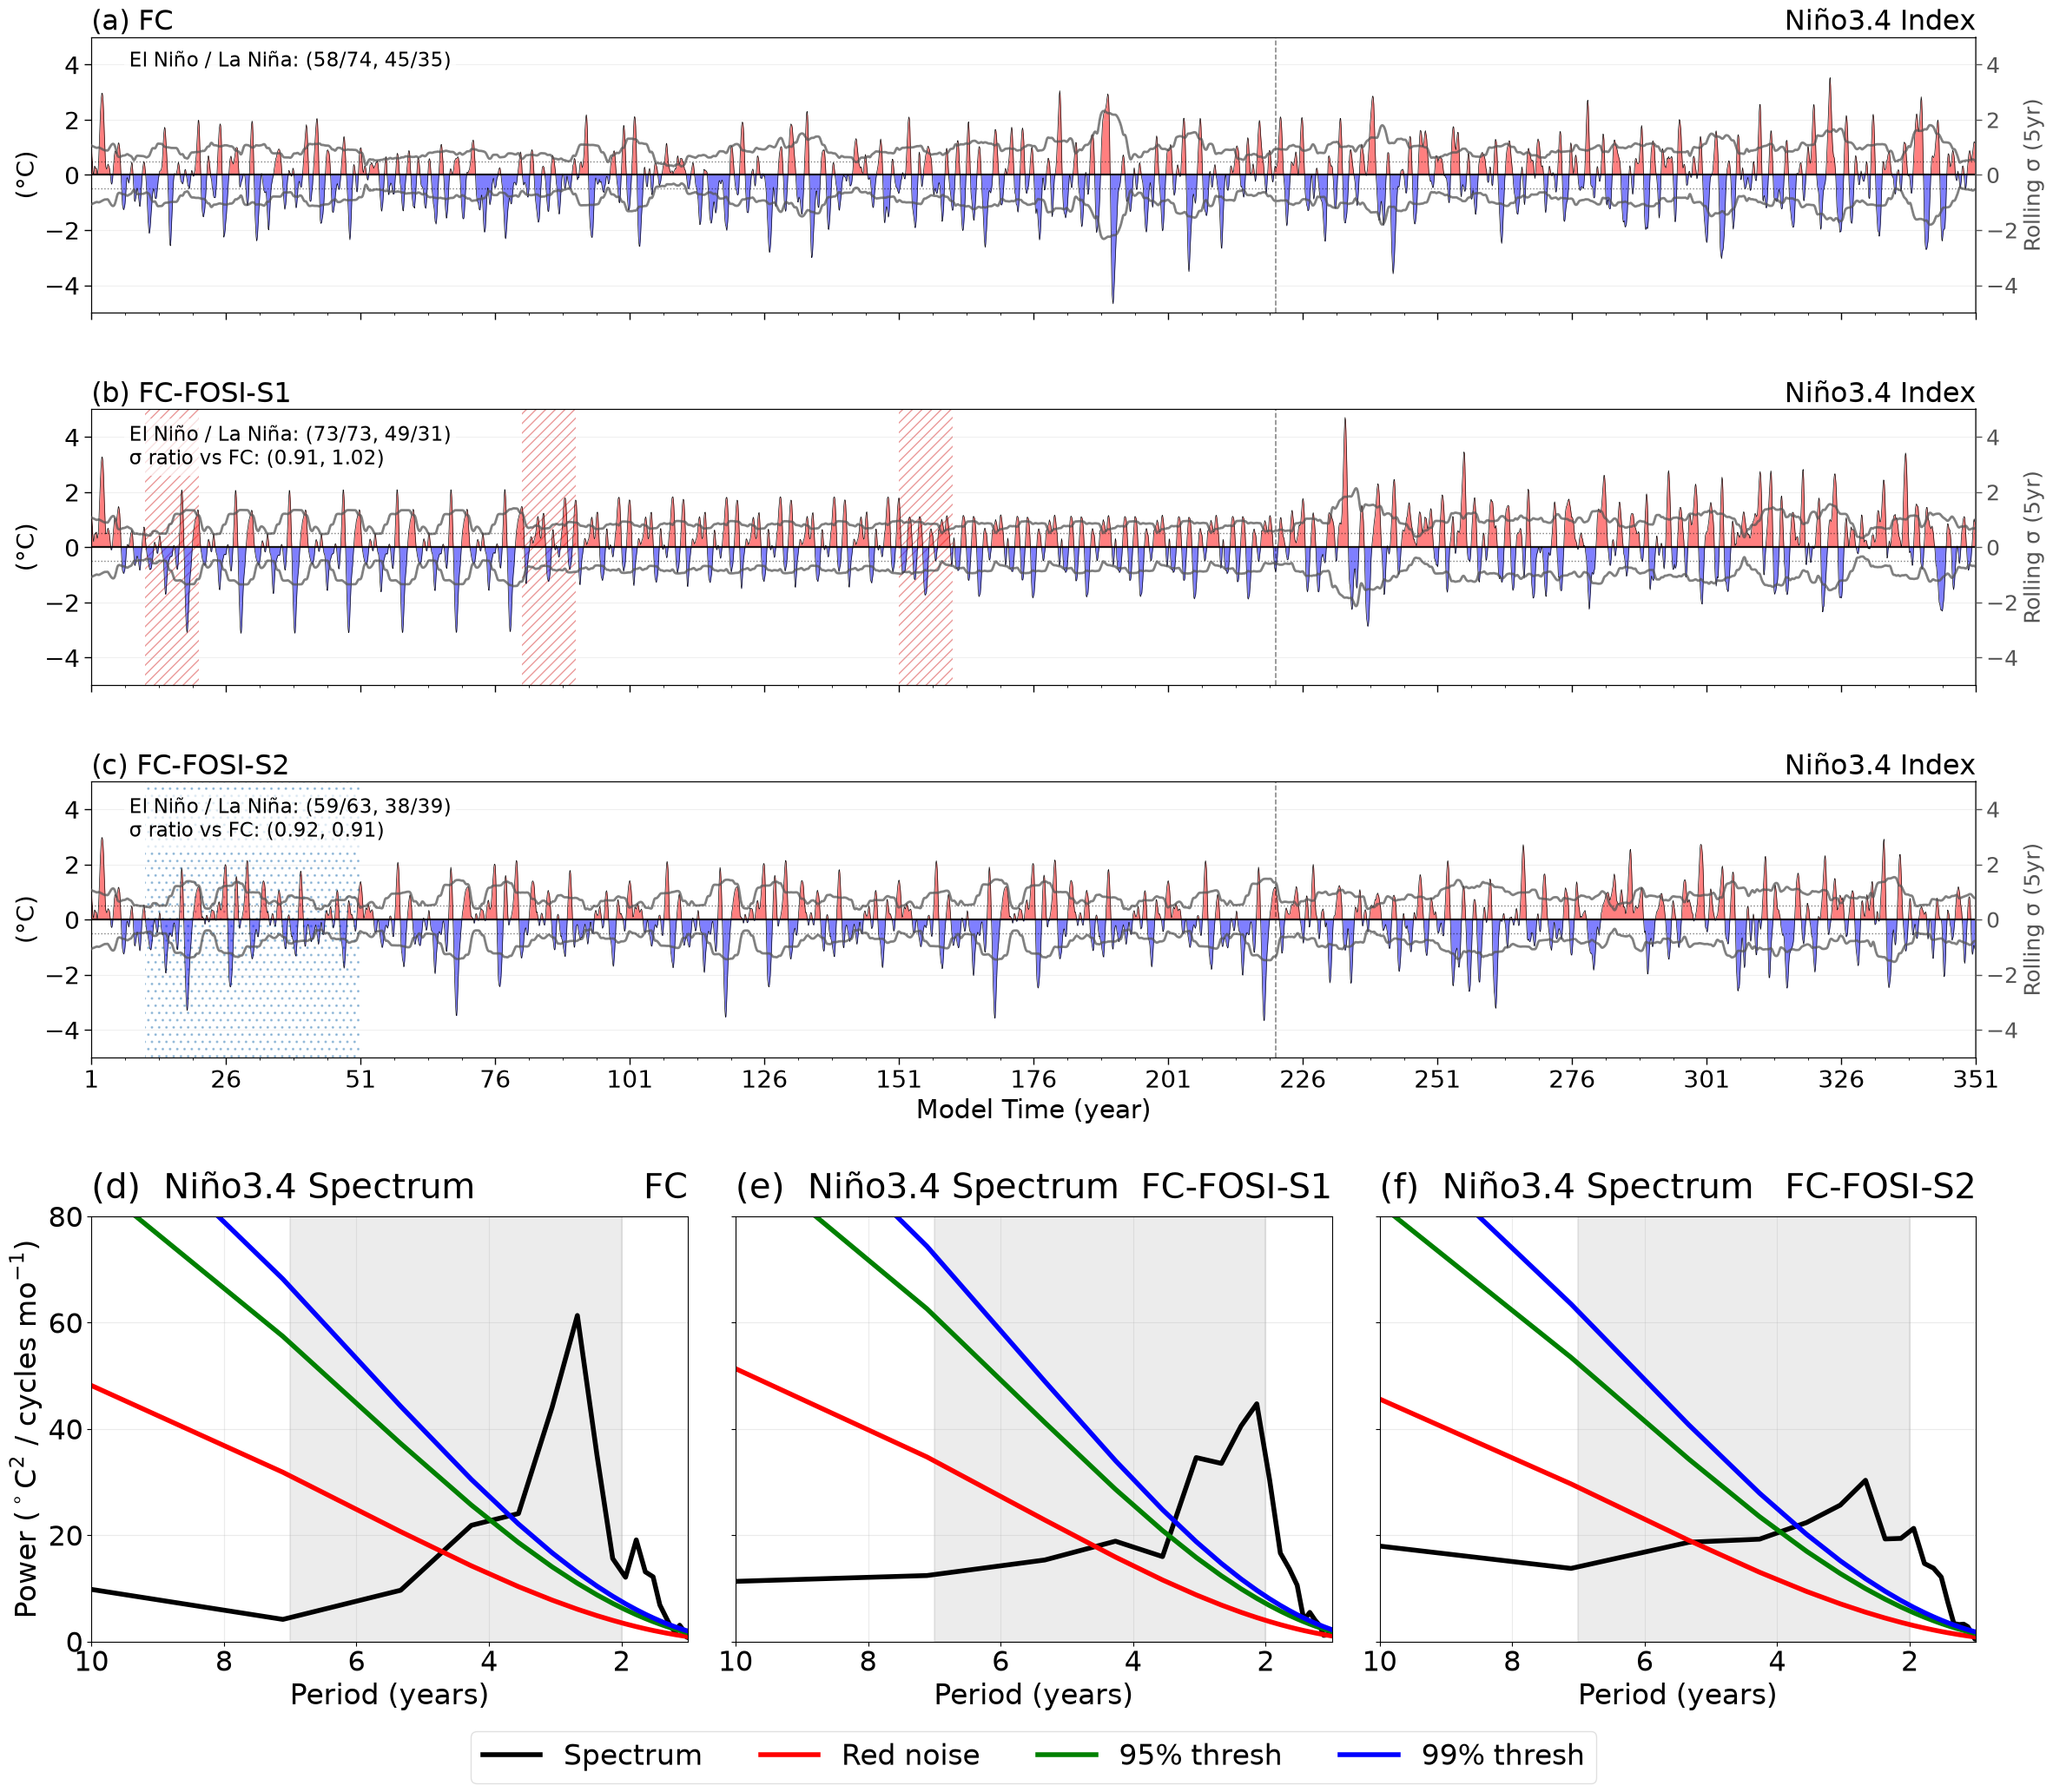

Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/enso/nino34_index_PSD_Welch_yr1-yr350_spec251-350.pdf
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/enso/nino34_index_PSD_Welch_yr1-yr350_spec251-350.pdf


In [10]:
# --- settings ---
combo_figsize      = (28, 24)
combo_fontsize     = 24
combo_height_ratios = (3.0, 1.25)   # index block (all index rows) : spectrum row
combo_hspace       = 0.22           # between the index block and the spectrum row
idx_hspace         = 0.35           # between index rows
psd_wspace         = 0.08           # between spectrum panels
combo_pdf = os.path.join(fig_dir, f"nino34_index_PSD_{method}_yr{year_min}-yr{year_max}_spec{enso_year1}-{enso_year2}.pdf")

# --- layout: one index row per experiment, then one row with all spectra ---
n_exp = len(exps)
fig = plt.figure(figsize=combo_figsize)
outer = fig.add_gridspec(2, 1, height_ratios=combo_height_ratios, hspace=combo_hspace)
gs_idx = outer[0].subgridspec(n_exp, 1, hspace=idx_hspace)
gs_psd = outer[1].subgridspec(1, len(psd_dict), wspace=psd_wspace)
idx_axes = [fig.add_subplot(gs_idx[0])]
idx_axes += [fig.add_subplot(gs_idx[r], sharex=idx_axes[0]) for r in range(1, n_exp)]
psd_axes = [fig.add_subplot(gs_psd[0])]
psd_axes += [fig.add_subplot(gs_psd[k], sharey=psd_axes[0]) for k in range(1, len(psd_dict))]

# (a)-(c): Niño3.4 index, same settings as section 2
plotter.plot_nino_index(
    title="Niño3.4 Index",
    y_label=ylab_idx,
    ylim=ylim_idx,
    x_label="Model Time (year)",
    colors=colors,
    fontsize=combo_fontsize,
    step_yrs=step_yrs,
    ref_yrs=ref_yrs,
    legend_loc=legend_loc,
    base_years=idx_base_years,
    smooth_months=idx_smooth_months,
    linestyle=linestyle,
    linewidth=linewidth,
    alpha=alpha,
    add_zero_line=add_zero_line,
    exp_shas=idx_shas,
    axes=idx_axes,
)
for ax in idx_axes[:-1]:
    ax.tick_params(labelbottom=False)

# (d)-(f): spectra, same settings as section 3, shared y axis
loader.plot_psd_panels(
    psd_dict=psd_dict,
    labels=labels_map,
    xlim=xlim,
    ylim=ylim,
    enso_band=enso_band,
    ylabel=ylabel,
    title=title,
    fontsize=combo_fontsize,
    fig_idx=n_exp,
    legend_at="bottom",
    legend_ncol=4,
    axes=psd_axes,
)
for ax in psd_axes[1:]:
    ax.set_ylabel("")
    ax.tick_params(labelleft=False)

fig.savefig(combo_pdf, dpi=600, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved:", combo_pdf)

publish(FIG_DIR, DATA_DIR)
print("web:", combo_pdf.replace(OUTPUT_ROOT, OUTPUT_URL))
